Importing Libraries

In [35]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler


Loading the Dataset

In [40]:
# Load data
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# Quick check
print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (49993, 44)
Val shape: (10774, 44)
Test shape: (10868, 44)


Preprocessing

In [42]:
P_COLS = [f"p{i}" for i in range(1, 43)]

# Split features and labels
X_train = train_df[P_COLS].to_numpy(dtype=np.float32)
y_train = train_df["label_move_col"].to_numpy(dtype=np.int64)

X_val = val_df[P_COLS].to_numpy(dtype=np.float32)
y_val = val_df["label_move_col"].to_numpy(dtype=np.int64)

X_test = test_df[P_COLS].to_numpy(dtype=np.float32)  # no labels

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# One-hot encode labels
num_classes = 7
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
print("Data ready:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("Unique labels:", np.unique(y_train))



Data ready:
X_train: (49993, 42) y_train: (49993,)
X_val: (10774, 42) y_val: (10774,)
X_test: (10868, 42)
Unique labels: [0 1 2 3 4 5 6]


Build Dense Model

In [46]:
model = Sequential([
    Input(shape=(42,)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,615 (205.53 KB)

 Trainable params: 52,615 (205.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Training the Model

In [49]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,
    batch_size=64,
    verbose=1
)


Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5730 - loss: 1.1259 - val_accuracy: 0.5766 - val_loss: 1.1092
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5729 - loss: 1.1253 - val_accuracy: 0.5820 - val_loss: 1.1045
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5748 - loss: 1.1170 - val_accuracy: 0.5790 - val_loss: 1.1064
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5772 - loss: 1.1154 - val_accuracy: 0.5829 - val_loss: 1.1046
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5758 - loss: 1.1174 - val_accuracy: 0.5773 - val_loss: 1.1083
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5739 - loss: 1.1158 - val_accuracy: 0.5790 - val_loss: 1.1076
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5776 - loss: 1.1128 - val_accuracy: 0.5795 - val_loss: 1.1051
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5746 - loss: 1.1169 - val_accuracy: 0.

Evaluation

In [51]:
val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")


Validation Accuracy: 0.5897


Plot Accuracy & Loss

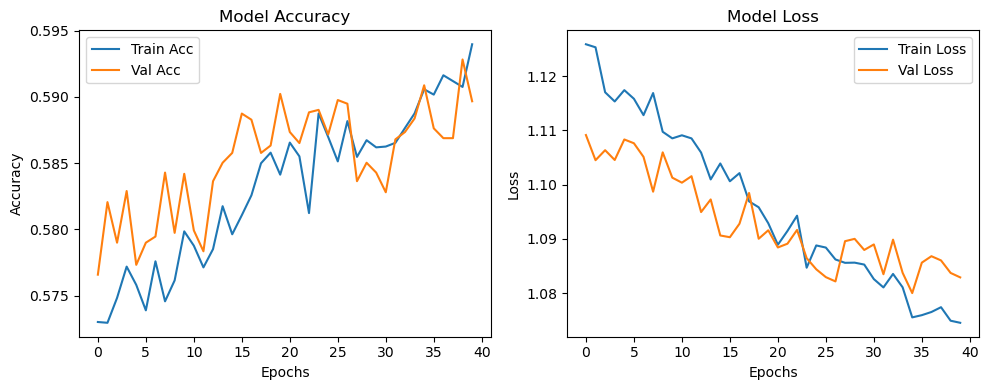

In [52]:
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Confusion Matrix

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


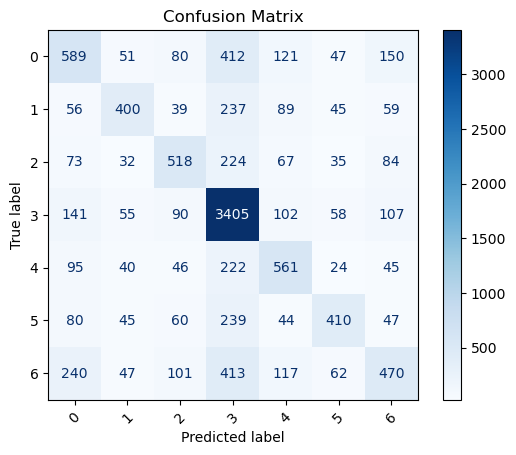

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict validation set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
